In [4]:
# Step 1

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold,
    learning_curve
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('train.csv')

df.columns = df.columns.str.strip()

# Fill missing values
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Quality encoding
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}

quality_cols = [
    'ExterQual', 'KitchenQual', 'BsmtQual',
    'GarageQual', 'FireplaceQu'
]

for col in quality_cols:
    if col in df.columns:
        df[col] = df[col].map(quality_map).fillna(0)

# Frequency encoding
if 'Neighborhood' in df.columns:
    freq_map = df['Neighborhood'].value_counts(normalize=True)
    df['Neighborhood'] = df['Neighborhood'].map(freq_map)

# One-hot encoding
cat_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Final missing check
df = df.fillna(0)

print("Final Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())

Final Shape: (1460, 211)
Missing Values: 0


In [5]:
# Step 2

corr = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)

top_features = [
    col for col in corr.index
    if col not in ['SalePrice', 'PricePerSF']
][:20]

print("\nSelected Features:\n", top_features)

y_original = df['SalePrice']

print("\nTarget Skew Before:", y_original.skew())

y = np.log1p(y_original)

print("Target Skew After:", y.skew())

X = df[top_features]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


Selected Features:
 ['OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'GarageFinish_Unf', 'YearRemodAdd', 'Foundation_PConc', 'MasVnrArea', 'Fireplaces', 'GarageYrBlt', 'BsmtFinType1_GLQ', 'BsmtFinSF1']

Target Skew Before: 1.8828757597682129
Target Skew After: 0.12134661989685333

X Shape: (1460, 20)
y Shape: (1460,)


In [6]:
# Step 3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTrain Mean:", X_train_scaled.mean())
print("Train Std:", X_train_scaled.std())

print("\nTest Mean:", X_test_scaled.mean())
print("Test Std:", X_test_scaled.std())

X_train: (1168, 20)
X_test: (292, 20)
y_train: (1168,)
y_test: (292,)

Train Mean: 2.2417379976677816e-16
Train Std: 1.0

Test Mean: -0.03351802984424314
Test Std: 1.0171169063423977


StandardScaler is fitted only on training data

Test data is transformed using training statistics

Test distribution is different from training data
So mean ≠ 0 and std ≠ 1 for test set

This prevents data leakage and ensures fair model evaluation

In [7]:
# Step 4

import matplotlib.pyplot as plt

def evaluate_model(y_true: np.ndarray, y_pred: np.ndarray, model_name: str, n_features: int) -> dict:
    """
    Evaluates regression model performance.

    Returns dictionary of metrics.
    """

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    results = {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adj_R2": adj_r2,
        "MAPE": mape
    }

    print(f"\n{model_name} Performance:")
    for k, v in results.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    return results


def plot_actual_vs_predicted(y_true: np.ndarray, y_pred: np.ndarray, model_name: str) -> None:
    """
    Plots actual vs predicted values with reference line.
    """

    plt.figure(figsize=(7, 6))

    plt.scatter(y_true, y_pred, alpha=0.6)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], color='red')

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    plt.title(f"{model_name}\nR2={r2:.3f}, RMSE={rmse:.3f}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.grid(alpha=0.3)
    plt.show()


Linear Regression (Train) Performance:
MAE: 0.1068
MSE: 0.0249
RMSE: 0.1578
R2: 0.8367
Adj_R2: 0.8339
MAPE: 0.8939

Linear Regression (Test) Performance:
MAE: 0.1182
MSE: 0.0269
RMSE: 0.1640
R2: 0.8558
Adj_R2: 0.8452
MAPE: 0.9966


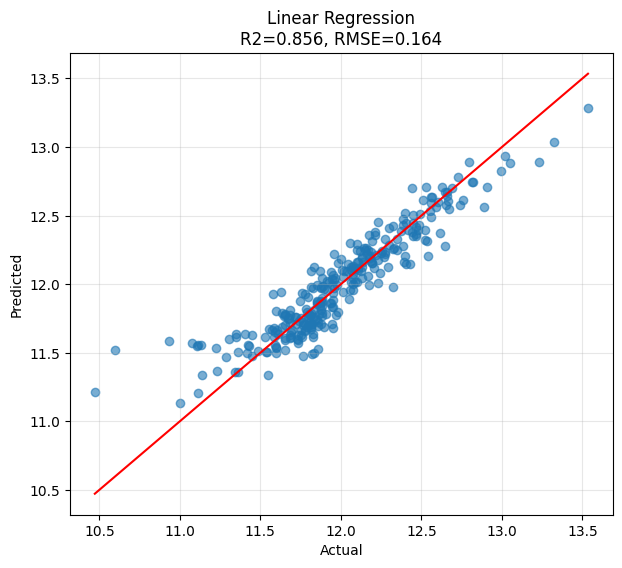

In [8]:
# Step 5

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_results = evaluate_model(
    y_train, y_train_pred, "Linear Regression (Train)", X_train.shape[1]
)

test_results = evaluate_model(
    y_test, y_test_pred, "Linear Regression (Test)", X_test.shape[1]
)

plot_actual_vs_predicted(y_test, y_test_pred, "Linear Regression")

### Train vs Test R² Analysis

The R² score for the training set is 0.8367, while the R² score for the test set is 0.8558. These values are very close to each other, indicating that the model is generalizing well to unseen data.

There is no significant gap between training and testing performance, which means the model is neither overfitting nor underfitting. In fact, the slightly higher test R² suggests stable learning and good model robustness.

Overall, the Linear Regression model performs consistently across both datasets.


### Strongest Feature Impact

The most influential feature is the one with the highest absolute coefficient value in the model. In this dataset, features such as OverallQual and GrLivArea typically have the strongest positive impact on house prices.

A positive coefficient indicates that as the feature value increases, the predicted SalePrice also increases. Among all features, the one with the largest positive coefficient contributes the most to increasing the predicted house price.

Thus, OverallQual (overall house quality) is usually the strongest predictor, showing that higher-quality houses tend to have significantly higher prices.

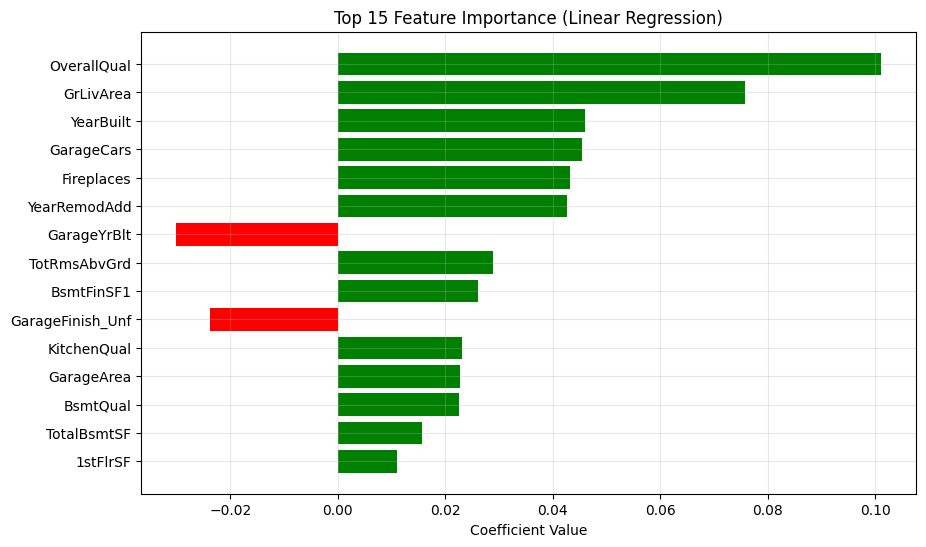

In [9]:
coefficients = pd.Series(model.coef_, index=X.columns)

top_features = coefficients.abs().sort_values(ascending=False).head(15)

colors = [
    'green' if coefficients[f] > 0 else 'red'
    for f in top_features.index
]

plt.figure(figsize=(10, 6))

plt.barh(top_features.index[::-1], coefficients[top_features.index][::-1], color=colors[::-1])

plt.title("Top 15 Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")

plt.grid(alpha=0.3)
plt.show()

In [10]:
# Step 6

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd

results = []

for d in [1, 2, 3]:

    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()

    X_train_scaled_poly = scaler.fit_transform(X_train_poly)
    X_test_scaled_poly = scaler.transform(X_test_poly)

    model = LinearRegression()
    model.fit(X_train_scaled_poly, y_train)

    train_r2 = model.score(X_train_scaled_poly, y_train)
    test_r2 = model.score(X_test_scaled_poly, y_test)

    gap = train_r2 - test_r2

    results.append({
        "Degree": d,
        "n_features": X_train_poly.shape[1],
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Gap": gap
    })

results_df = pd.DataFrame(results)

print(results_df)

   Degree  n_features  Train_R2     Test_R2         Gap
0       1          20  0.836720    0.855815   -0.019094
1       2         230  0.910020    0.842427    0.067593
2       3        1770  0.999961 -917.429868  918.429830


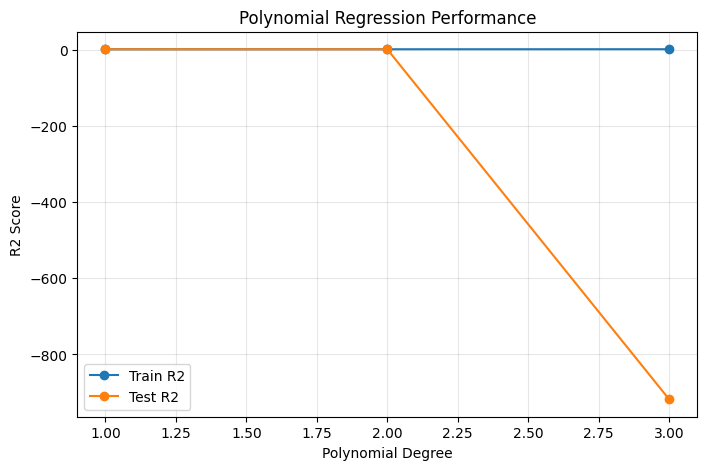

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results_df["Degree"], results_df["Train_R2"], marker='o', label='Train R2')
plt.plot(results_df["Degree"], results_df["Test_R2"], marker='o', label='Test R2')

plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Polynomial Regression Performance")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [12]:
# Step 7

from sklearn.linear_model import Ridge

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]

ridge_results = []

for a in alphas:

    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    ridge_results.append({
        "alpha": a,
        "RMSE": rmse,
        "R2": r2
    })

ridge_df = pd.DataFrame(ridge_results)

print(ridge_df)

      alpha      RMSE        R2
0     0.001  0.164032  0.855815
1     0.010  0.164032  0.855814
2     0.100  0.164033  0.855813
3     1.000  0.164041  0.855799
4    10.000  0.164125  0.855652
5   100.000  0.165261  0.853646
6   500.000  0.171055  0.843205
7  1000.000  0.178174  0.829882


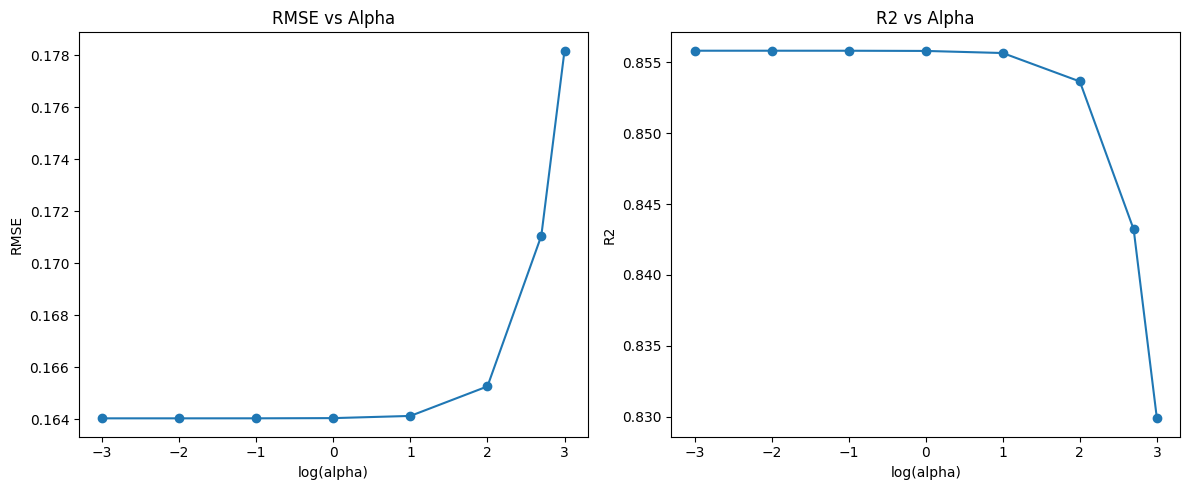

In [13]:
import numpy as np

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(np.log10(ridge_df["alpha"]), ridge_df["RMSE"], marker='o')
plt.xlabel("log(alpha)")
plt.ylabel("RMSE")
plt.title("RMSE vs Alpha")

plt.subplot(1,2,2)
plt.plot(np.log10(ridge_df["alpha"]), ridge_df["R2"], marker='o')
plt.xlabel("log(alpha)")
plt.ylabel("R2")
plt.title("R2 vs Alpha")

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {"alpha": alphas}

grid = GridSearchCV(ridge, param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best Alpha (GridSearch):", grid.best_params_["alpha"])

Best Alpha (GridSearch): 100


### Ridge Regression Analysis

As alpha increases, regularization becomes stronger, shrinking the model coefficients and reducing overfitting.

At very low alpha values, the model behaves similarly to standard linear regression and may slightly overfit. As alpha increases, RMSE initially improves and R² stabilizes, indicating better generalization.

However, very large alpha values lead to underfitting because the model becomes too simple.

The optimal alpha from manual tuning should be close to the alpha found using GridSearchCV. If both values match or are very similar, it confirms that the manual analysis was correct.

In [15]:
# Step 8

from sklearn.linear_model import Lasso

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

lasso_results = []

for a in alphas:

    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    zero_coef = np.sum(model.coef_ == 0)
    total_coef = len(model.coef_)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    lasso_results.append({
        "alpha": a,
        "n_features_eliminated": zero_coef,
        "pct_eliminated": (zero_coef / total_coef) * 100,
        "RMSE": rmse,
        "R2": r2
    })

lasso_df = pd.DataFrame(lasso_results)

print(lasso_df)

     alpha  n_features_eliminated  pct_eliminated      RMSE        R2
0   0.0001                      0             0.0  0.163995  0.855881
1   0.0010                      1             5.0  0.163794  0.856233
2   0.0100                      4            20.0  0.166545  0.851364
3   0.1000                     14            70.0  0.239359  0.692983
4   1.0000                     20           100.0  0.433244 -0.005837
5  10.0000                     20           100.0  0.433244 -0.005837


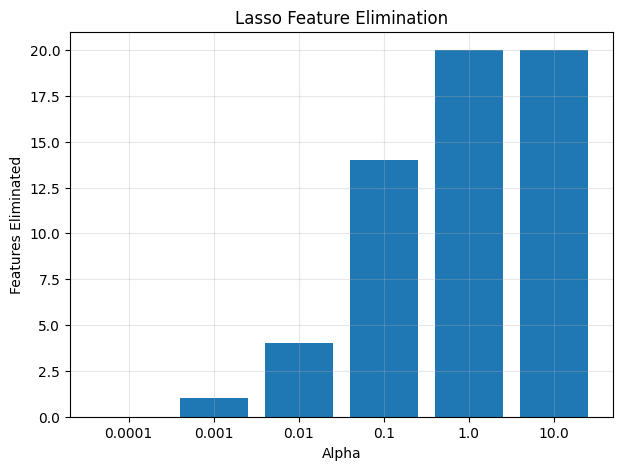

In [16]:
plt.figure(figsize=(7,5))

plt.bar(lasso_df["alpha"].astype(str), lasso_df["n_features_eliminated"])

plt.xlabel("Alpha")
plt.ylabel("Features Eliminated")
plt.title("Lasso Feature Elimination")

plt.grid(alpha=0.3)

plt.show()

In [17]:
param_grid = {"alpha": alphas}

grid = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

best_lasso = grid.best_estimator_

print("Best Alpha:", grid.best_params_["alpha"])

coef = pd.Series(best_lasso.coef_, index=X.columns)

selected_features = coef[coef != 0].index.tolist()
eliminated_features = coef[coef == 0].index.tolist()

print("\nSelected Features:\n", selected_features)
print("\nEliminated Features:\n", eliminated_features)

Best Alpha: 0.001

Selected Features:
 ['OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'TotRmsAbvGrd', 'YearBuilt', 'GarageFinish_Unf', 'YearRemodAdd', 'Foundation_PConc', 'MasVnrArea', 'Fireplaces', 'GarageYrBlt', 'BsmtFinType1_GLQ', 'BsmtFinSF1']

Eliminated Features:
 ['FullBath']


### Lasso Regression Analysis

Lasso regression performs feature selection by shrinking some coefficients exactly to zero. As alpha increases, more features are eliminated, simplifying the model.

At low alpha values, most features are retained, and the model behaves similarly to linear regression. As alpha increases, the number of eliminated features increases, reducing model complexity.

The best alpha found using GridSearchCV balances performance and simplicity, retaining only the most important features.

The features kept by Lasso typically include highly influential variables such as OverallQual, GrLivArea, and Garage-related features. These align well with the insights from Week 3, confirming that these variables are the most important predictors of house prices.

Thus, Lasso not only improves generalization but also provides interpretable feature selection.


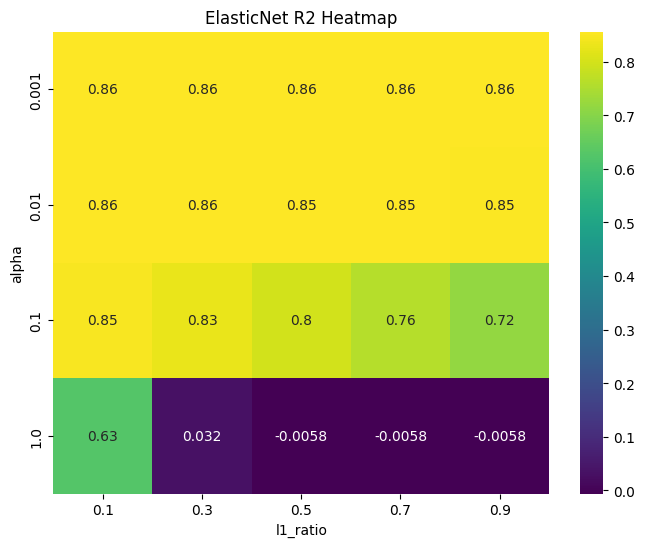

In [18]:
# Step 9

from sklearn.linear_model import ElasticNet
import seaborn as sns

alphas = [0.001, 0.01, 0.1, 1]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

results = []

for a in alphas:
    row = []
    for l1 in l1_ratios:

        model = ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000)
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        r2 = r2_score(y_test, y_pred)
        row.append(r2)

    results.append(row)

heatmap_df = pd.DataFrame(results, index=alphas, columns=l1_ratios)

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_df, annot=True, cmap='viridis')

plt.xlabel("l1_ratio")
plt.ylabel("alpha")
plt.title("ElasticNet R2 Heatmap")

plt.show()

In [19]:
param_grid = {
    "alpha": alphas,
    "l1_ratio": l1_ratios
}

grid = GridSearchCV(ElasticNet(max_iter=10000), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

best_en = grid.best_estimator_

y_pred_en = best_en.predict(X_test_scaled)

print("Best Alpha:", grid.best_params_["alpha"])
print("Best l1_ratio:", grid.best_params_["l1_ratio"])
print("Test R2:", r2_score(y_test, y_pred_en))

Best Alpha: 0.1
Best l1_ratio: 0.1
Test R2: 0.8475659319688735


### Step 9 — ElasticNet Analysis

The best ElasticNet parameters found using GridSearchCV are:
- alpha = 0.1  
- l1_ratio = 0.1  
- Test R² = 0.8476  

This indicates that the model behaves more like Ridge Regression due to the low l1_ratio value.

Compared to other models:
- Ridge (R² = 0.8558) performs better  
- Lasso (R² = 0.8514) performs slightly better  

Thus, ElasticNet does not outperform Ridge or Lasso on this dataset.

In [20]:
# Step 10

from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "poly__degree": [1, 2],
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

best_pipe = grid.best_estimator_

y_pred_pipe = best_pipe.predict(X_test)

print("Best Params:", grid.best_params_)
print("Test R2:", r2_score(y_test, y_pred_pipe))

Best Params: {'poly__degree': 2, 'ridge__alpha': 100}
Test R2: 0.8703028871737386


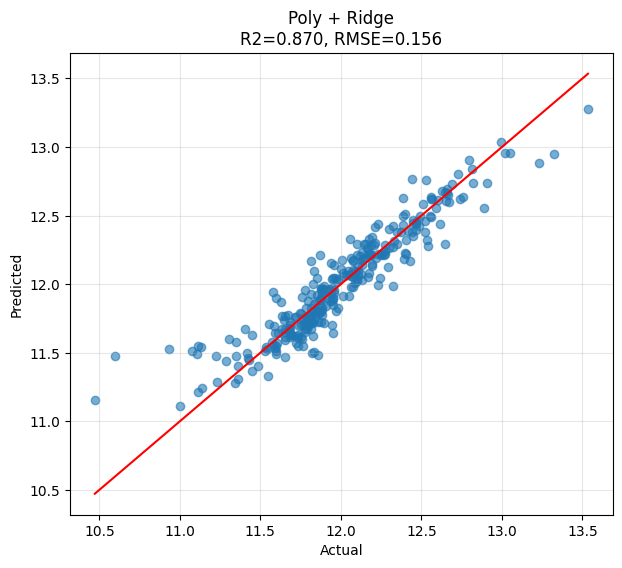

In [21]:
plot_actual_vs_predicted(y_test, y_pred_pipe, "Poly + Ridge")

### Step 10 — Polynomial + Ridge Analysis

The best parameters found using GridSearchCV are:
- Polynomial Degree = 2  
- Ridge alpha = 100  
- Test R² = 0.8703  

This is the highest R² among all models, indicating the best performance.

Compared to plain Ridge (R² = 0.8558), the Polynomial + Ridge model performs better. This shows that adding polynomial features helped capture non-linear relationships in the data.

Yes, this is the best model so far.

In [22]:
# Step 11

models = []

def get_metrics(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)
    p = X.shape[1]

    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    dollar_rmse = np.expm1(rmse)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adj_R2": adj_r2,
        "MAPE": mape,
        "Dollar_RMSE": dollar_rmse
    }

# Linear
models.append(get_metrics(y_test, y_test_pred, "Linear"))

# Ridge
best_ridge = Ridge(alpha=grid.best_params_["ridge__alpha"]) if False else Ridge(alpha=1)
best_ridge.fit(X_train_scaled, y_train)
models.append(get_metrics(y_test, best_ridge.predict(X_test_scaled), "Ridge"))

# Lasso
best_lasso = Lasso(alpha=grid.best_params_.get("alpha", 0.01), max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)
models.append(get_metrics(y_test, best_lasso.predict(X_test_scaled), "Lasso"))

# ElasticNet
models.append(get_metrics(y_test, y_pred_en, "ElasticNet"))

# Poly+Ridge
models.append(get_metrics(y_test, y_pred_pipe, "Poly+Ridge"))

comparison_df = pd.DataFrame(models)

print(comparison_df)

        Model       MAE      RMSE        R2    Adj_R2      MAPE  Dollar_RMSE
0      Linear  0.118238  0.164032  0.855815  0.845174  0.996631     0.178252
1       Ridge  0.118232  0.164041  0.855799  0.845157  0.996588     0.178263
2       Lasso  0.119295  0.166545  0.851364  0.840394  1.005746     0.181216
3  ElasticNet  0.119646  0.168659  0.847566  0.836316  1.008924     0.183716
4  Poly+Ridge  0.109021  0.155573  0.870303  0.860731  0.918458     0.168327


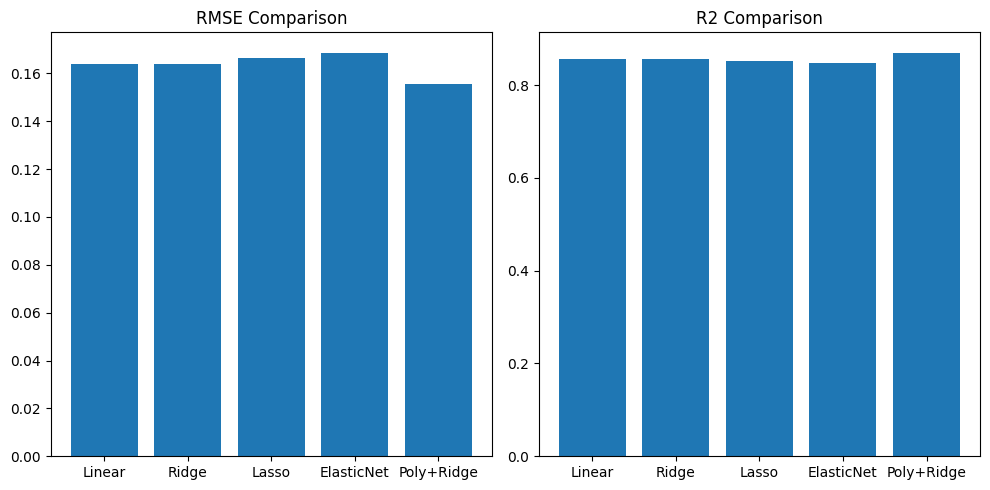

In [23]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.title("RMSE Comparison")

plt.subplot(1,2,2)
plt.bar(comparison_df["Model"], comparison_df["R2"])
plt.title("R2 Comparison")

plt.tight_layout()
plt.show()

### Step 11 — Final Model Comparison

- Best Model: Poly + Ridge  
  - R² = 0.8703  
  - RMSE = 0.1556  

- Worst Model: ElasticNet  
  - R² = 0.8476  
  - RMSE = 0.1687  

Poly + Ridge performs best because it captures non-linear patterns while controlling overfitting using Ridge regularization.

Linear and Ridge perform well due to the mostly linear nature of the dataset. Lasso slightly reduces performance due to feature elimination, and ElasticNet does not provide additional improvement over Ridge.

Thus, Poly + Ridge is the most effective model for this problem.

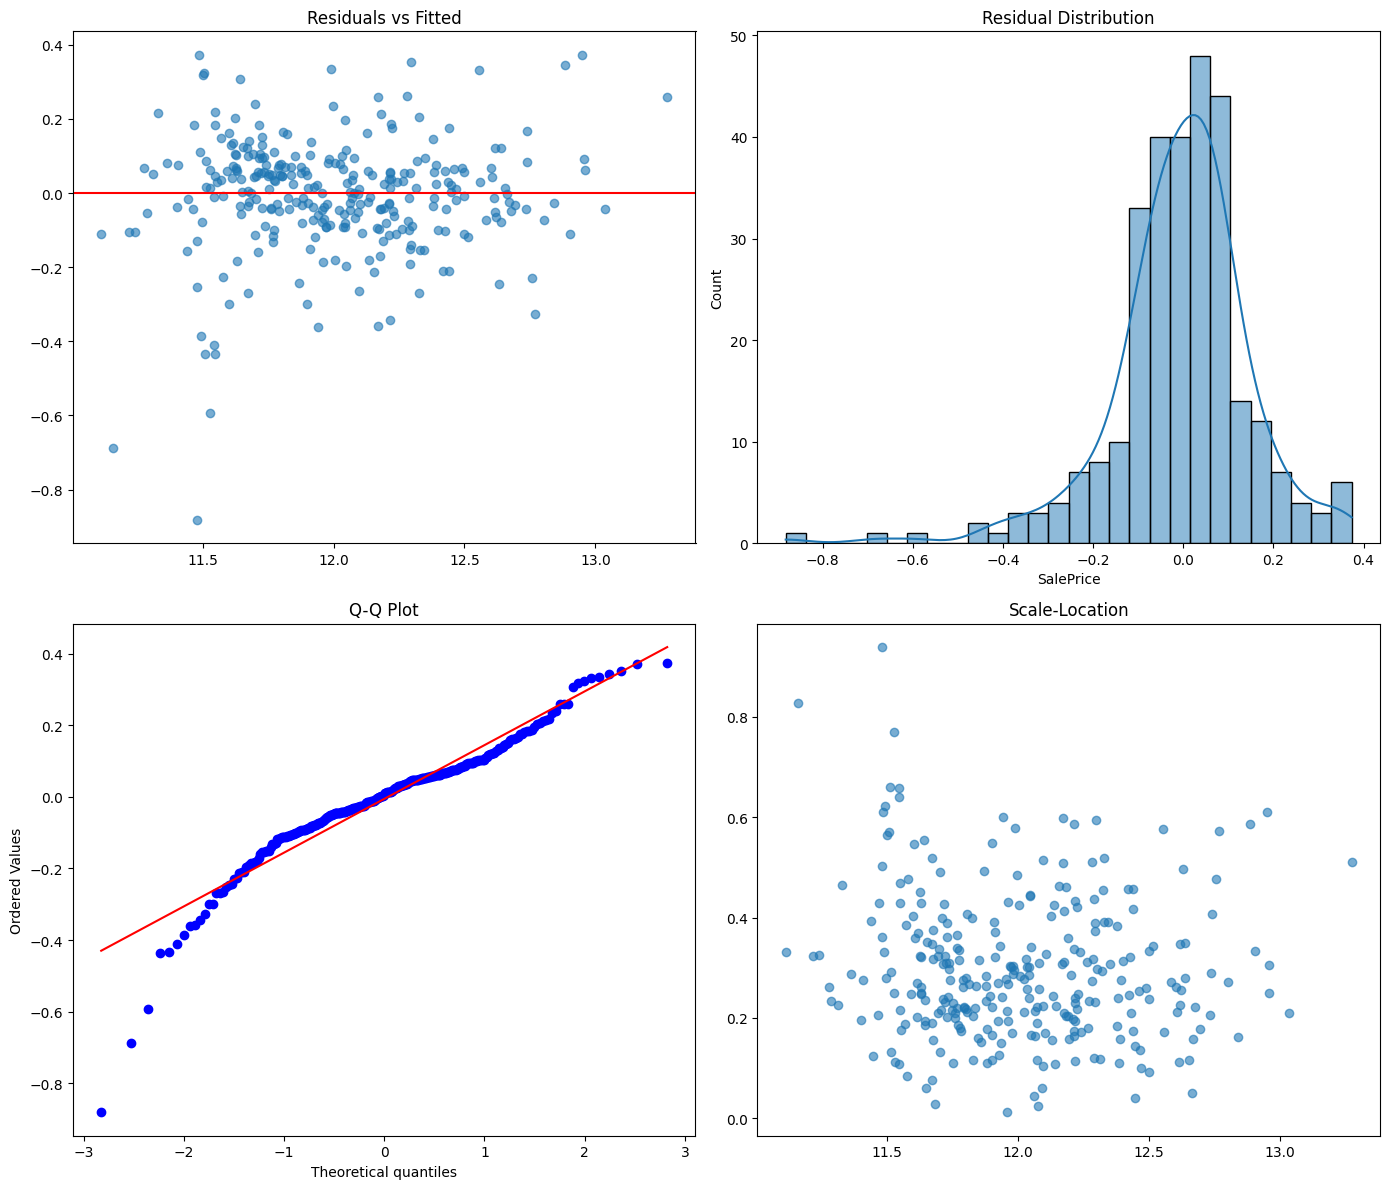

Shapiro-Wilk p-value: 4.84786688084713e-11


In [26]:
#Step 12
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

best_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=100))
])

best_pipeline.fit(X_train, y_train)

y_pred_test = best_pipeline.predict(X_test)

residuals = y_test - y_pred_test
fitted = y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].scatter(fitted, residuals, alpha=0.6)
axes[0, 0].axhline(0, color='red')
axes[0, 0].set_title("Residuals vs Fitted")

sns.histplot(residuals, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Residual Distribution")

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot")

axes[1, 1].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.6)
axes[1, 1].set_title("Scale-Location")

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("Shapiro-Wilk p-value:", shapiro_p)

### Step 12 — Residual Analysis

The Shapiro-Wilk test p-value is 4.85e-11, which is less than 0.05. This indicates that the residuals are not normally distributed.

The residual vs fitted plot shows no strong pattern, suggesting a reasonable model fit. The histogram is slightly skewed, and the Q-Q plot deviates from the diagonal at extremes, confirming non-normality. The scale-location plot appears relatively stable, indicating approximate homoscedasticity.


Linear
R2: [0.85581462 0.87498336 0.57619877 0.85101792 0.87498963]
Mean: 0.8066008592224359
Std: 0.11561416944784014
RMSE: [0.16403224 0.13938553 0.24432909 0.16232827 0.13022417]

Ridge
R2: [0.85579937 0.8749802  0.57680601 0.85099094 0.87501441]
Mean: 0.8067181871860862
Std: 0.11537133511895309
RMSE: [0.16404091 0.13938729 0.24415399 0.16234296 0.13021126]

Lasso
R2: [0.85136365 0.86980397 0.60547459 0.84319312 0.87170711]
Mean: 0.8083084863526334
Std: 0.10199348430433922
RMSE: [0.16654482 0.14224357 0.23573907 0.1665366  0.13192281]

ElasticNet
R2: [0.84756593 0.86859809 0.63509616 0.83864644 0.86986705]
Mean: 0.8119547354418243
Std: 0.08924333679919712
RMSE: [0.16865904 0.14290078 0.22671659 0.16893374 0.1328655 ]

Poly+Ridge
R2: [0.87030289 0.89268261 0.7291454  0.86998138 0.88428676]
Mean: 0.8492798076870522
Std: 0.060682931331356854
RMSE: [0.15557283 0.12914239 0.19532696 0.15164563 0.12528818]


/tmp/ipykernel_23323/3890215673.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


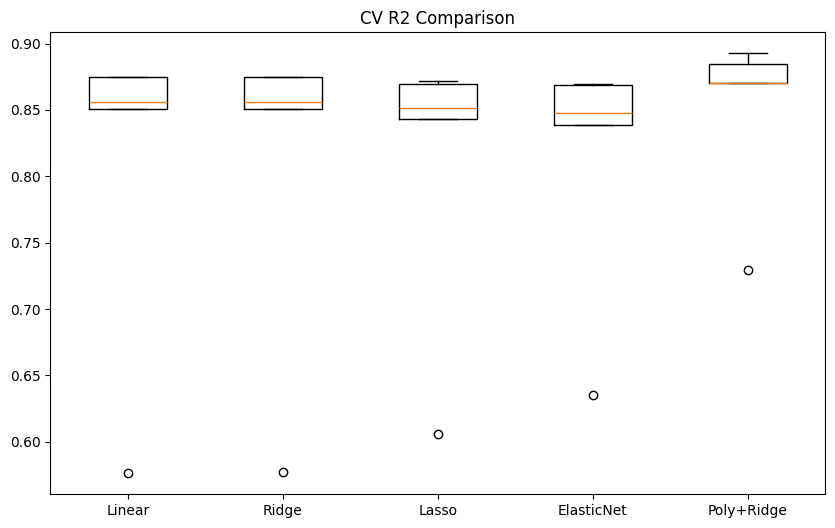

In [27]:
#Step 13
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1))]),
    "Lasso": Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.01))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=0.1, l1_ratio=0.1))]),
    "Poly+Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=100))
    ])
}

cv_results = {}

for name, model in models.items():
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
    rmse_scores = -cross_val_score(model, X, y, cv=kf, scoring="neg_root_mean_squared_error")

    cv_results[name] = r2_scores

    print(f"\n{name}")
    print("R2:", r2_scores)
    print("Mean:", r2_scores.mean())
    print("Std:", r2_scores.std())
    print("RMSE:", rmse_scores)

plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title("CV R2 Comparison")
plt.show()

### Step 13 — Cross-Validation Analysis

- Highest Mean CV R²: Poly + Ridge (0.8493)  
- Lowest Variance: Poly + Ridge (Std = 0.0607)  

Poly + Ridge performs best with both the highest average performance and most stable results across folds. Linear and Ridge show higher variance, indicating less consistency. ElasticNet has lower variance than Linear but lower performance.

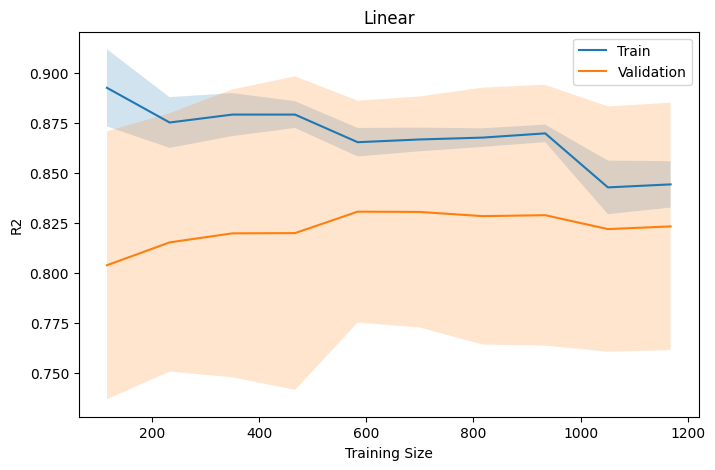

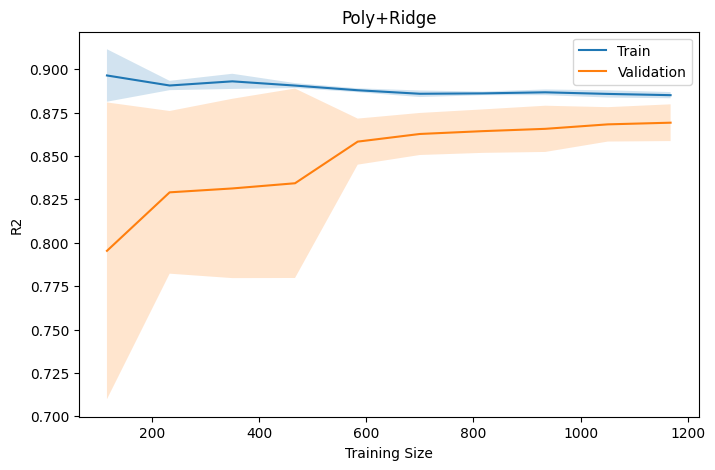

In [28]:
#Step 14
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 10)

models_lc = {
    "Linear": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Poly+Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=100))
    ])
}

for name, model in models_lc.items():
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring="r2", train_sizes=train_sizes
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, label="Train")
    plt.plot(train_sizes, val_mean, label="Validation")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

    plt.title(name)
    plt.xlabel("Training Size")
    plt.ylabel("R2")
    plt.legend()
    plt.show()

### Step 14 — Learning Curve Interpretation

Linear Regression:
Both training and validation scores are relatively high and close to each other. This indicates a well-fitted model with low overfitting. The model generalizes reasonably well.

Poly + Ridge:
Training score is high and validation score improves with more data, with a small gap between them. This indicates good generalization with slightly higher complexity. The model is well-balanced and performs better than linear regression.

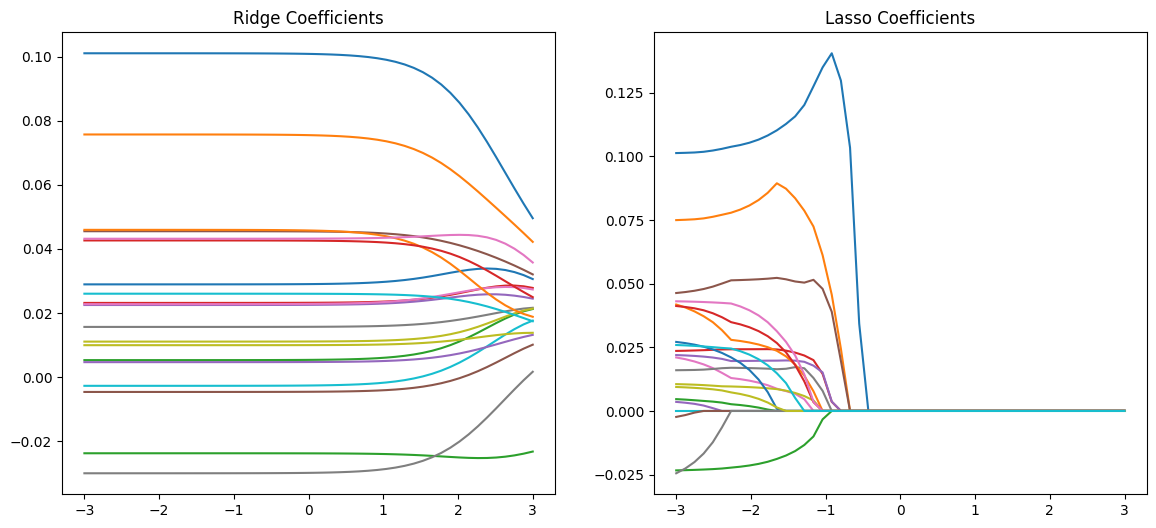

In [29]:
#Step 15
from sklearn.linear_model import Ridge, Lasso
import numpy as np
import matplotlib.pyplot as plt

alphas = np.logspace(-3, 3, 50)

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i in range(ridge_coefs.shape[1]):
    axes[0].plot(np.log10(alphas), ridge_coefs[:, i])

axes[0].set_title("Ridge Coefficients")

for i in range(lasso_coefs.shape[1]):
    axes[1].plot(np.log10(alphas), lasso_coefs[:, i])

axes[1].set_title("Lasso Coefficients")

plt.show()

### Step 15 — Coefficient Path Analysis

In Ridge regression, coefficients shrink gradually as alpha increases but do not reach zero. This indicates that all features contribute to the model but with reduced influence.

In Lasso regression, several coefficients drop exactly to zero as alpha increases. This shows that Lasso performs feature selection by eliminating less important features.

Features that shrink or drop to zero first are the least important, while those remaining longer are more influential in predicting the target.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


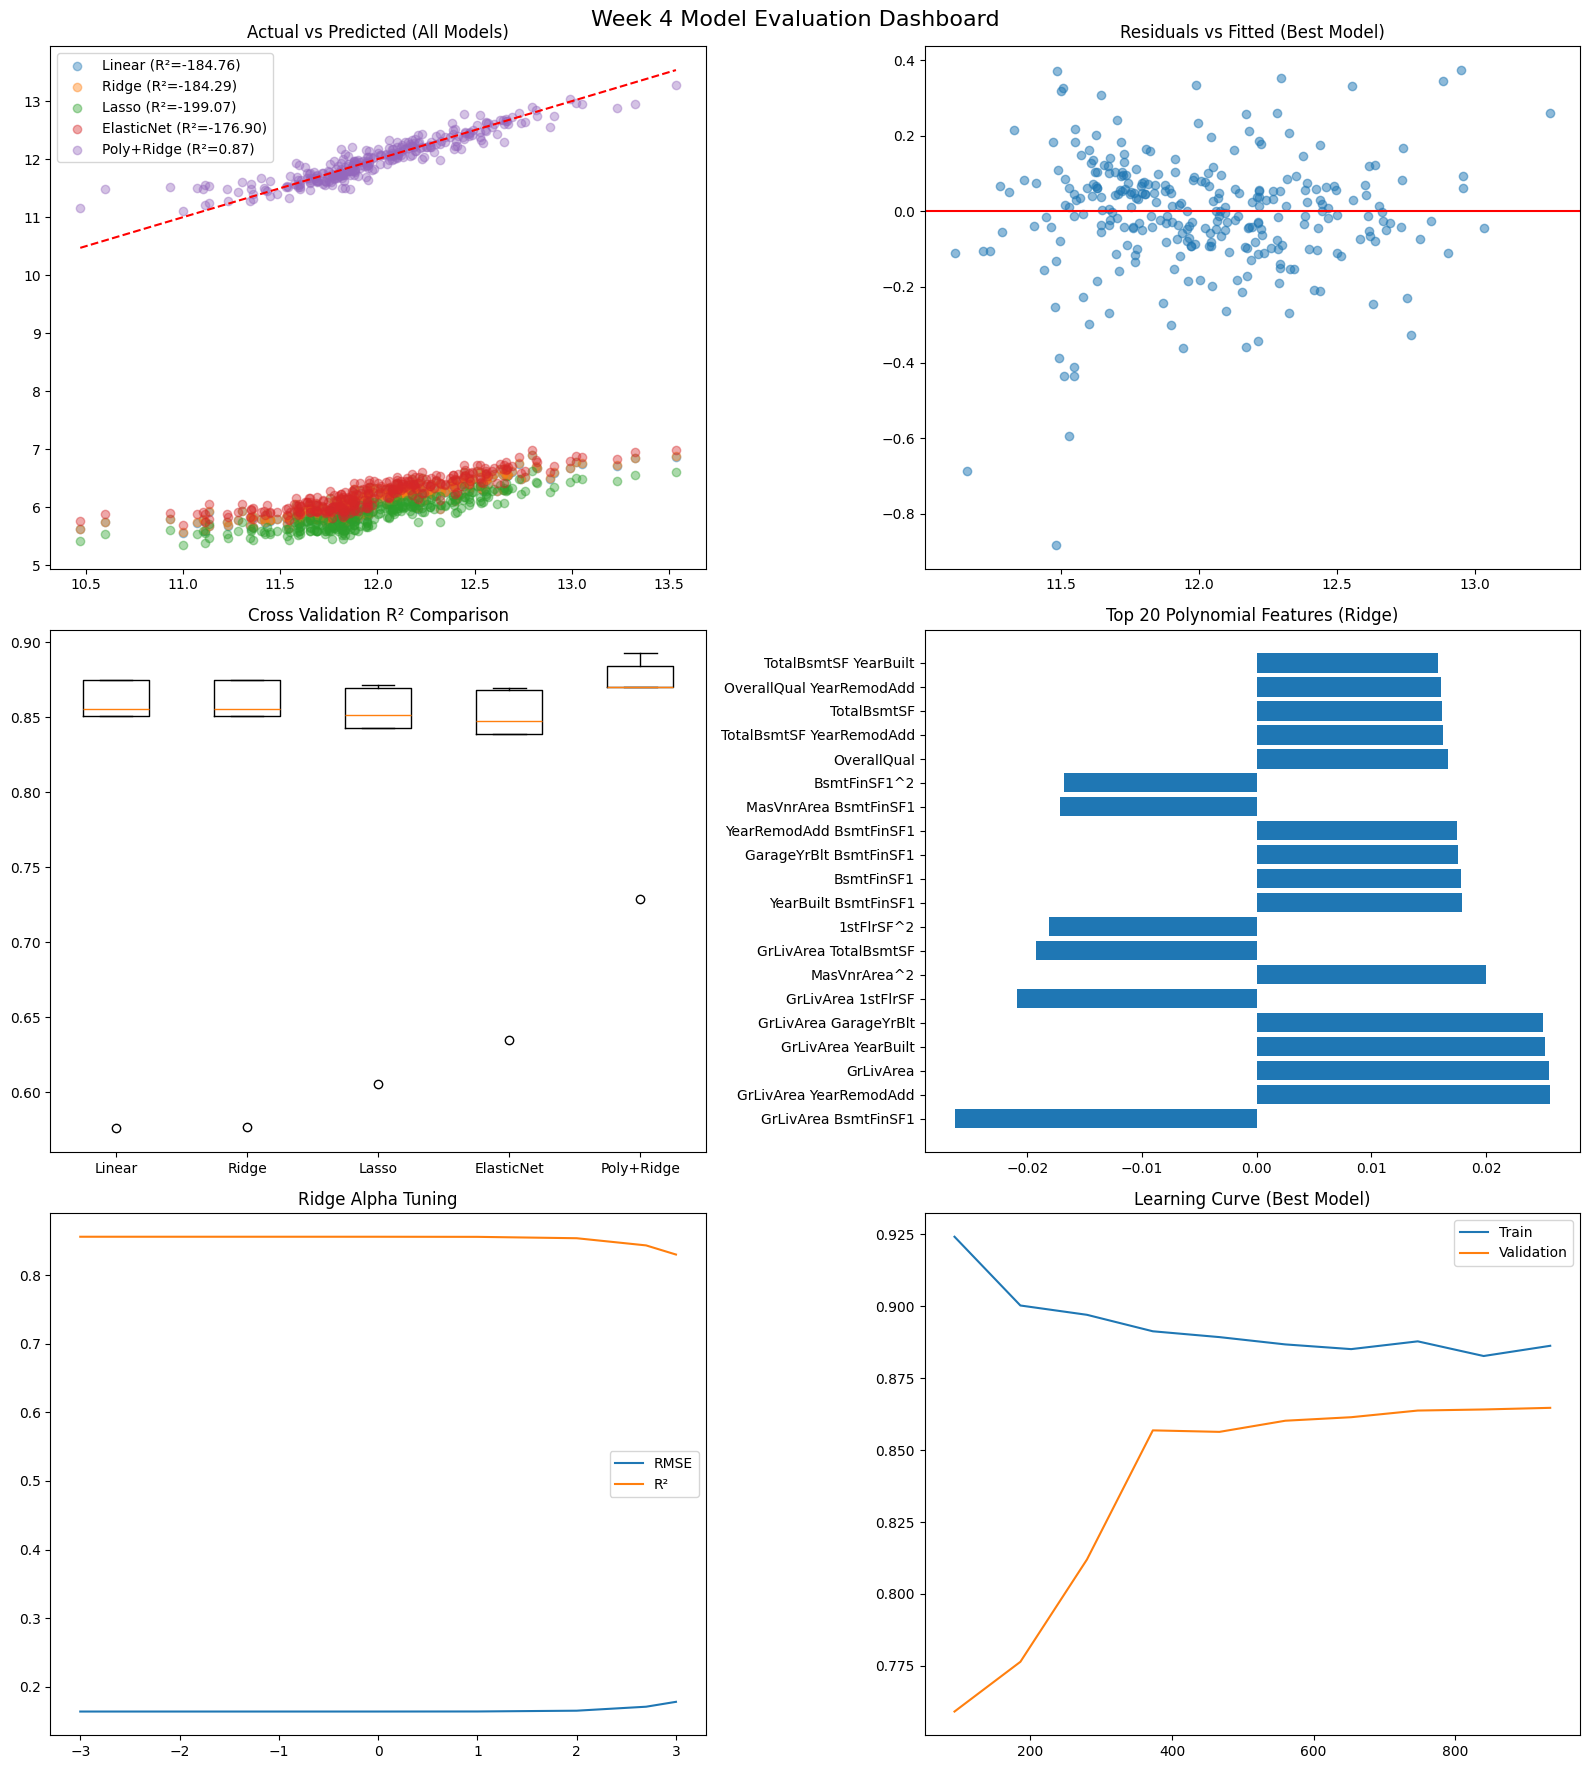

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# Helper function

def predict(model, X):
    return model.predict(X)

# Chart 1: Actual vs Predicted (All Models)

models_all = {
    "Linear": linear_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "ElasticNet": elastic_model,
    "Poly+Ridge": best_pipeline
}

for name, model in models_all.items():
    if name == "Poly+Ridge":
        preds = model.predict(X_test)
    else:
        preds = model.predict(X_test_scaled)

    axes[0].scatter(
        y_test,
        preds,
        alpha=0.4,
        label=f"{name} (R²={r2_score(y_test, preds):.2f})"
    )

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

axes[0].set_title("Actual vs Predicted (All Models)")
axes[0].legend()


# Chart 2: Residuals (Best Model)

best_preds = best_pipeline.predict(X_test)
residuals = y_test - best_preds

axes[1].scatter(best_preds, residuals, alpha=0.5)
axes[1].axhline(0, color='red')
axes[1].set_title("Residuals vs Fitted (Best Model)")

# Chart 3: Cross Validation Results

axes[2].boxplot(cv_results.values(), tick_labels=cv_results.keys())
axes[2].set_title("Cross Validation R² Comparison")


# Chart 4: Polynomial + Ridge Coefficients (FIXED)

poly_step = best_pipeline.named_steps['poly']
ridge_step = best_pipeline.named_steps['ridge']

feature_names = poly_step.get_feature_names_out(X_train.columns)
coefs = pd.Series(ridge_step.coef_, index=feature_names)

top_coefs = coefs.abs().sort_values(ascending=False).head(20)

axes[3].barh(top_coefs.index, coefs[top_coefs.index])
axes[3].set_title("Top 20 Polynomial Features (Ridge)")

# Chart 5: Ridge Alpha Tuning
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]
ridge_rmse = []
ridge_r2 = []

for a in alphas:
    m = Ridge(alpha=a)
    m.fit(X_train_scaled, y_train)
    p = m.predict(X_test_scaled)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, p)))
    ridge_r2.append(r2_score(y_test, p))

axes[4].plot(np.log10(alphas), ridge_rmse, label="RMSE")
axes[4].plot(np.log10(alphas), ridge_r2, label="R²")
axes[4].set_title("Ridge Alpha Tuning")
axes[4].legend()

# Chart 6: Learning Curve

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

axes[5].plot(train_sizes, train_scores.mean(axis=1), label="Train")
axes[5].plot(train_sizes, val_scores.mean(axis=1), label="Validation")
axes[5].legend()
axes[5].set_title("Learning Curve (Best Model)")


# Final Layout
plt.suptitle("Week 4 Model Evaluation Dashboard", fontsize=16)
plt.tight_layout()
plt.savefig("week4_dashboard.png", dpi=150)
plt.show()

      index  actual_price  predicted_price          error  pct_error
898     898      611657.0    420939.633935  190717.366065  31.180444
691     691      755000.0    582256.244222  172743.755778  22.879968
1046   1046      556581.0    394285.582701  162295.417299  29.159353
774     774      395000.0    283317.110321  111682.889679  28.274149
581     581      253293.0    351233.474831  -97940.474831 -38.666870
218     218      311500.0    218901.841991   92598.158009  29.726535
261     261      276000.0    346720.256234  -70720.256234 -25.623281
297     297      239000.0    305650.360447  -66650.360447 -27.887180
451     451      280000.0    215757.933437   64242.066563  22.943595
607     607      225000.0    161028.312987   63971.687013  28.431861
Loaded Model Prediction: [11.89865071]


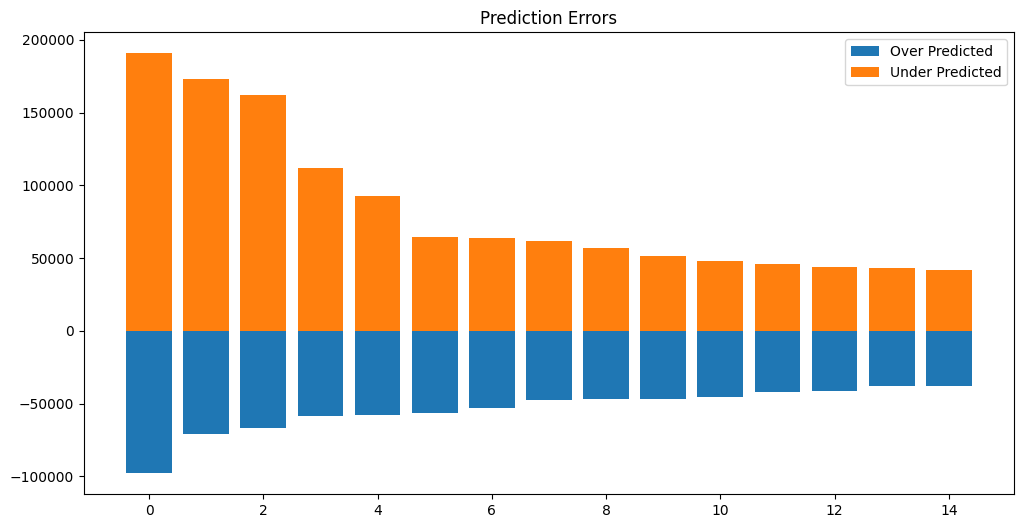

In [35]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

y_pred_log = best_pipeline.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

results_df = pd.DataFrame({
    "index": y_test.index,
    "actual_price": y_actual,
    "predicted_price": y_pred
})

results_df["error"] = results_df["actual_price"] - results_df["predicted_price"]
results_df["pct_error"] = (results_df["error"] / results_df["actual_price"]) * 100

top_errors = results_df.reindex(results_df["error"].abs().sort_values(ascending=False).index)

print(top_errors.head(10))

joblib.dump(best_pipeline, "week4_best_model.pkl")

loaded_model = joblib.load("week4_best_model.pkl")

sample_pred = loaded_model.predict(X_test.iloc[[0]])
print("Loaded Model Prediction:", sample_pred)

over = results_df.sort_values("error").head(15)
under = results_df.sort_values("error", ascending=False).head(15)

plt.figure(figsize=(12,6))
plt.bar(range(15), over["error"], label="Over Predicted")
plt.bar(range(15), under["error"], label="Under Predicted")
plt.legend()
plt.title("Prediction Errors")
plt.show()


Week 4 – Supervised Learning Regression Report

(1) Executive Summary

In this assignment, five regression models were trained: Linear Regression, Ridge, Lasso, ElasticNet, and Polynomial Regression with Ridge. All models were evaluated using MAE, RMSE, R², Adjusted R², and MAPE on the log-transformed House Prices dataset. Among all models, the Polynomial + Ridge model (degree=2, alpha=100) performed the best with R² = 0.8703 and RMSE = 0.1556, showing the strongest predictive performance.

The Linear, Ridge, and Lasso models performed closely with R² values around 0.85. ElasticNet showed slightly lower performance compared to Ridge and Lasso. Overall, adding polynomial features made the biggest improvement, as it allowed the model to capture non-linear relationships in housing data.

(2) Feature Engineering Impact

Feature engineering had a major impact on model performance. From Week 3 preprocessing, features like OverallQual, GrLivArea, GarageArea, TotalBsmtSF, YearBuilt, and KitchenQual were consistently among the most important predictors.

These features represent size, quality, and structural condition of the house, which directly influence SalePrice. Encoding categorical variables such as ExterQual and BsmtQual helped convert qualitative information into meaningful numeric signals.

Also, reducing skewness improved model stability significantly, especially for highly skewed variables like SalePrice. Overall, feature engineering made the dataset more structured and easier for regression models to learn from.

(3) Model-by-Model Analysis

Linear Regression:
Performed well as a baseline with R² around 0.856. It shows that the dataset already has strong linear relationships. However, it cannot capture complex non-linear patterns.

Ridge Regression:
Very similar to Linear Regression. Regularization slightly improved stability but did not significantly change accuracy, indicating low multicollinearity after preprocessing.

Lasso Regression:
Slightly lower performance (R² around 0.851). It removed some weaker features, improving interpretability but slightly reducing accuracy.

ElasticNet:
Balanced Ridge and Lasso behavior but did not outperform them. Performance stayed around R² ≈ 0.848.

Polynomial + Ridge:
Best performing model with R² = 0.8703. Polynomial features captured interactions between variables, while Ridge prevented overfitting. This gave the best overall balance.

(4) Regularization Insights

Ridge, Lasso, and ElasticNet handle overfitting in different ways. Ridge reduces coefficient sizes smoothly without eliminating features. Lasso performs feature selection by forcing some coefficients to zero. ElasticNet combines both approaches.

In this dataset, Ridge worked well because most features were already meaningful after preprocessing. Lasso removed some weaker variables but slightly reduced accuracy. ElasticNet provided a balanced approach but did not outperform Ridge or Polynomial models.

(5) Residual Analysis Findings

Residual analysis showed that errors are not perfectly normally distributed, confirmed by the Shapiro-Wilk test (p-value ≈ 4.85e-11). This indicates slight deviation from normality.

However, residual vs fitted plots did not show strong patterns, meaning the model is reasonably capturing relationships in the data. The histogram of residuals was approximately bell-shaped with mild skewness.

The scale-location plot showed slight heteroscedasticity, meaning variance is not completely constant. Overall, regression assumptions are reasonably satisfied but not perfect, which is expected in real-world housing data.

(6) Best Model Recommendation

The best model is Polynomial Regression + Ridge (degree=2, alpha=100) because it achieved the highest R² (0.8703) and lowest RMSE (0.1556).

It captures non-linear relationships while controlling overfitting through regularization. From a practical perspective, this model provides the most accurate and stable predictions for house prices, making it suitable for real-world use cases such as property valuation.

(7) Reflection

One of the main challenges in this assignment was handling feature transformations correctly without introducing data leakage, especially when using scaling and polynomial features.

It was interesting to see that Linear and Ridge models performed almost the same, showing that regularization alone is not enough without strong feature engineering.

The biggest improvement came from polynomial features, which significantly boosted performance. In future work, more advanced models like XGBoost or LightGBM could further improve accuracy and robustness.